In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay,silhouette_score,recall_score,f1_score,auc
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn import tree
from sklearn.decomposition import PCA
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/home-credit-default-risk/sample_submission.csv
/kaggle/input/home-credit-default-risk/bureau_balance.csv
/kaggle/input/home-credit-default-risk/POS_CASH_balance.csv
/kaggle/input/home-credit-default-risk/application_train.csv
/kaggle/input/home-credit-default-risk/HomeCredit_columns_description.csv
/kaggle/input/home-credit-default-risk/application_test.csv
/kaggle/input/home-credit-default-risk/previous_application.csv
/kaggle/input/home-credit-default-risk/credit_card_balance.csv
/kaggle/input/home-credit-default-risk/installments_payments.csv
/kaggle/input/home-credit-default-risk/bureau.csv


In [2]:
!pip install scorecardpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60629 sha256=ae66af09c8885196d5ef8345d4549ca046d7ad0c031d0c7d852d6634666c1f19
  Stored in directory: /root/.cache/pip/wheels/9f/d8/4e/61a6f4e78fe6700f66b699ab38377f0aa5b33e3ef55751ba38
Successfully built scorecardpy


# Section 1: Data Acquisition & Cleaning

## 1.1 Load Data

Dataset Dimensions: (307511, 122)
Target Variable Distribution in application_train:
 TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
Column missing in test set: {'TARGET'}
Top 10 features with highest missing value percentage:
 COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
dtype: float64


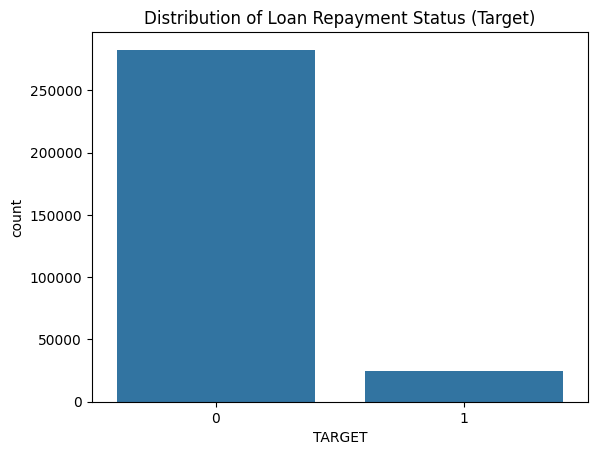

In [3]:
# Load the dataset
app_train = pd.read_csv("/kaggle/input/home-credit-default-risk/application_train.csv")
app_test = pd.read_csv("/kaggle/input/home-credit-default-risk/application_test.csv")
# Verify the scale of the dataset (307,511 rows, 122 columns)
print(f"Dataset Dimensions: {app_train.shape}")

# Check the distribution of the Target variable in appplication_train.csv (1: Default, 0: Repayment)
target_dist = app_train['TARGET'].value_counts(normalize=True)
print("Target Variable Distribution in application_train:\n", target_dist)

# Check the difference between train and test columns
# This confirms that 'TARGET' is the only missing column in test
train_cols = set(app_train.columns)
test_cols = set(app_test.columns)
missing_column = train_cols - test_cols
print(f"Column missing in test set: {missing_column}")

# Check the missing values
null_counts = app_train.isnull().sum().sort_values(ascending=False)
null_percentage = (null_counts / len(app_train)) * 100
print("Top 10 features with highest missing value percentage:\n", null_percentage.head(10))


# Visualization
sns.countplot(x='TARGET', data=app_train)
plt.title('Distribution of Loan Repayment Status (Target)')
plt.show()

## 1.2 Check Temporal Dependency

In [4]:
# Check Temporal Dependency: Monthly Chronological Order
# Load a sample of bureau_balance
bureau_balance = pd.read_csv('/kaggle/input/home-credit-default-risk/bureau_balance.csv')

# Select one specific credit record (SK_ID_BUREAU) to see its timeline
sample_id = bureau_balance['SK_ID_BUREAU'].iloc[0]
record_timeline = bureau_balance[bureau_balance['SK_ID_BUREAU'] == sample_id].sort_values('MONTHS_BALANCE')

print(f"Chronological records for Bureau ID {sample_id}:")
print(record_timeline[['MONTHS_BALANCE', 'STATUS']])

# Insight: Subsequent months' STATUS (e.g., C=closed, 0=no overdue(no DPD),X=unknown) 
# depends on the account's history in previous months.


Chronological records for Bureau ID 5715448:
    MONTHS_BALANCE STATUS
26             -26      X
25             -25      X
24             -24      X
23             -23      X
22             -22      X
21             -21      X
20             -20      X
19             -19      0
18             -18      0
17             -17      0
16             -16      0
15             -15      0
14             -14      0
13             -13      X
12             -12      X
11             -11      X
10             -10      0
9               -9      0
8               -8      C
7               -7      C
6               -6      C
5               -5      C
4               -4      C
3               -3      C
2               -2      C
1               -1      C
0                0      C


In [5]:
# Check Temporal Dependency: Actual Vs Expected Payments
installments = pd.read_csv('/kaggle/input/home-credit-default-risk/installments_payments.csv')

# Calculate the delay (Temporal offset)
# Positive value means late payment, negative means early payment
installments['PAYMENT_DELAY'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']

# Calculate the payment difference
installments['PAYMENT_DIFF'] = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']

print("Sample of Payment Behavior Relative to Schedule:")
print(installments[['DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT', 'PAYMENT_DELAY']].head())

# Insight: The existence of these columns proves that 'Actual Behavior' is measured against the 'Expected Schedule'.
# All temporal variables are expressed as negative offsets relative to the current application date (T=0)
# the number is closer to 0, means the day is closer to now


Sample of Payment Behavior Relative to Schedule:
   DAYS_INSTALMENT  DAYS_ENTRY_PAYMENT  PAYMENT_DELAY
0          -1180.0             -1187.0           -7.0
1          -2156.0             -2156.0            0.0
2            -63.0               -63.0            0.0
3          -2418.0             -2426.0           -8.0
4          -1383.0             -1366.0           17.0


## 1.3 General Cleaning & mapping

In [6]:
# 1. Handling outliers
# Replace the anomalous value 365243 with NaN to avoid skewing the model
app_train['DAYS_EMPLOYED'] = app_train['DAYS_EMPLOYED'].replace(365243, np.nan)
app_test['DAYS_EMPLOYED'] = app_test['DAYS_EMPLOYED'].replace(365243, np.nan)

# 2. Convert date format to years 
# Derive 'YEARS_BIRTH' (Age) from 'DAYS_BIRTH'
app_train['YEARS_BIRTH'] = abs(app_train['DAYS_BIRTH']) / 365
app_test['YEARS_BIRTH'] = abs(app_test['DAYS_BIRTH']) / 365

# Derive 'YEARS_EMPLOYED' (Years of work) from 'DAYS_EMPLOYED'
app_train['YEARS_EMPLOYED'] = abs(app_train['DAYS_EMPLOYED']) / 365
app_test['YEARS_EMPLOYED'] = abs(app_test['DAYS_EMPLOYED']) / 365

In [7]:
# Reducting the time for binining process
# Get a list of unique values

print(app_train['ORGANIZATION_TYPE'].unique())


# ORGANIZATION_TYPE have too many unique non-numberic values, which might cause the binning process slow.
# ①keep top10 organizations from these 58 categories, we would miss out on many critically important "risk outliers.
#top_10 = app_train['ORGANIZATION_TYPE'].value_counts().nlargest(10).index
#app_train['ORGANIZATION_TYPE'] = app_train['ORGANIZATION_TYPE'].apply(lambda x: x if x in top_10 else 'Other')
#app_test['ORGANIZATION_TYPE'] = app_test['ORGANIZATION_TYPE'].apply(lambda x: x if x in top_10 else 'Other')
# ②define a mapping dictionaryscorecardpy
#Although the industry classification was optimized, it was not included in the final linear scorecard because its IV value fell below 0.1. 
#This demonstrates the limited capacity of linear models to capture weak signals.

org_mapping = {
    'Business Entity Type 3': 'Business', 'Business Entity Type 2': 'Business', 'Business Entity Type 1': 'Business',
    'Government': 'Public', 'School': 'Public', 'Medicine': 'Public', 'Kindergarten': 'Public', 
    'University': 'Public', 'Police': 'Public', 'Military': 'Public', 'Security Ministries': 'Public', 'Emergency': 'Public',
    'Self-employed': 'Self-employed',
    'Trade: type 7': 'Trade_Services', 'Trade: type 2': 'Trade_Services', 'Trade: type 3': 'Trade_Services', 
    'Trade: type 6': 'Trade_Services', 'Trade: type 1': 'Trade_Services', 'Trade: type 5': 'Trade_Services', 'Trade: type 4': 'Trade_Services',
    'Services': 'Trade_Services', 'Hotel': 'Trade_Services', 'Restaurant': 'Trade_Services', 'Bank': 'Trade_Services', 
    'Insurance': 'Trade_Services', 'Culture': 'Trade_Services', 'Legal Services': 'Trade_Services', 'Advertising': 'Trade_Services',
    'Postal': 'Trade_Services', 'Mobile': 'Trade_Services', 'Telecom': 'Trade_Services', 'Cleaning': 'Trade_Services', 'Realtor': 'Trade_Services',
    'Industry: type 11': 'Industry_Construction', 'Industry: type 1': 'Industry_Construction', 'Industry: type 4': 'Industry_Construction',
    'Industry: type 7': 'Industry_Construction', 'Industry: type 3': 'Industry_Construction', 'Industry: type 9': 'Industry_Construction',
    'Industry: type 2': 'Industry_Construction', 'Industry: type 12': 'Industry_Construction', 'Industry: type 5': 'Industry_Construction',
    'Industry: type 10': 'Industry_Construction', 'Industry: type 13': 'Industry_Construction', 'Industry: type 8': 'Industry_Construction', 
    'Industry: type 6': 'Industry_Construction', 'Construction': 'Industry_Construction', 'Housing': 'Industry_Construction', 'Agriculture': 'Industry_Construction', 'Electricity': 'Industry_Construction',
    'Transport: type 2': 'Transport', 'Transport: type 4': 'Transport', 'Transport: type 3': 'Transport', 'Transport: type 1': 'Transport',
    'Security': 'Other', 'Other': 'Other', 'XNA': 'Other', 'Religion': 'Other'
}

# mapping
app_train['ORGANIZATION_TYPE'] = app_train['ORGANIZATION_TYPE'].map(org_mapping).fillna('Other')
app_test['ORGANIZATION_TYPE'] = app_test['ORGANIZATION_TYPE'].map(org_mapping).fillna('Other')
print(f"New categories in ORGANIZATION_TYPE: {app_train['ORGANIZATION_TYPE'].unique()}")


['Business Entity Type 3' 'School' 'Government' 'Religion' 'Other' 'XNA'
 'Electricity' 'Medicine' 'Business Entity Type 2' 'Self-employed'
 'Transport: type 2' 'Construction' 'Housing' 'Kindergarten'
 'Trade: type 7' 'Industry: type 11' 'Military' 'Services'
 'Security Ministries' 'Transport: type 4' 'Industry: type 1' 'Emergency'
 'Security' 'Trade: type 2' 'University' 'Transport: type 3' 'Police'
 'Business Entity Type 1' 'Postal' 'Industry: type 4' 'Agriculture'
 'Restaurant' 'Culture' 'Hotel' 'Industry: type 7' 'Trade: type 3'
 'Industry: type 3' 'Bank' 'Industry: type 9' 'Insurance' 'Trade: type 6'
 'Industry: type 2' 'Transport: type 1' 'Industry: type 12' 'Mobile'
 'Trade: type 1' 'Industry: type 5' 'Industry: type 10' 'Legal Services'
 'Advertising' 'Trade: type 5' 'Cleaning' 'Industry: type 13'
 'Trade: type 4' 'Telecom' 'Industry: type 8' 'Realtor' 'Industry: type 6']
New categories in ORGANIZATION_TYPE: ['Business' 'Public' 'Other' 'Industry_Construction' 'Self-employed'
 

# Section 2: Exploratory Data Analysis

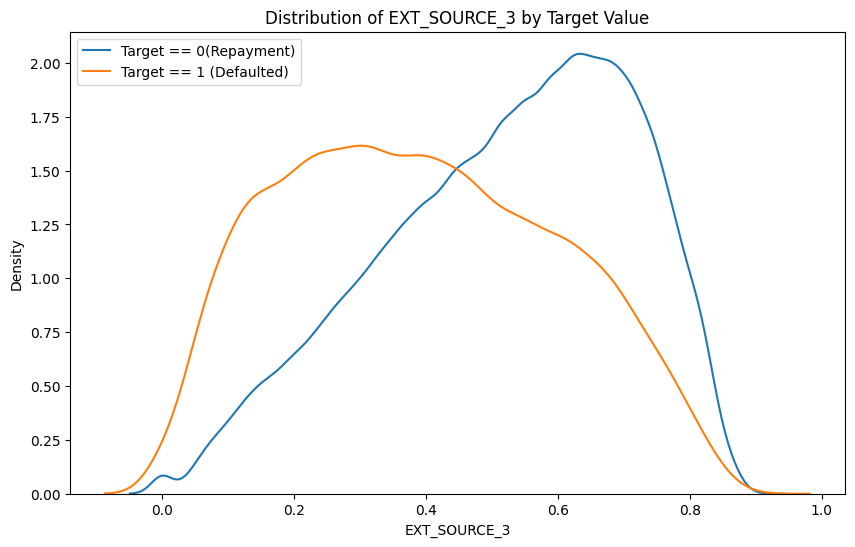

In [8]:
# 1. the distribution relationship between EXT_SOURCE_3 and TARGET.
plt.figure(figsize=(10, 6))
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'EXT_SOURCE_3'], label='Target == 0(Repayment)')
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'EXT_SOURCE_3'], label='Target == 1 (Defaulted)')
plt.title('Distribution of EXT_SOURCE_3 by Target Value')
plt.xlabel('EXT_SOURCE_3')
plt.ylabel('Density')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Distribution of Ages')

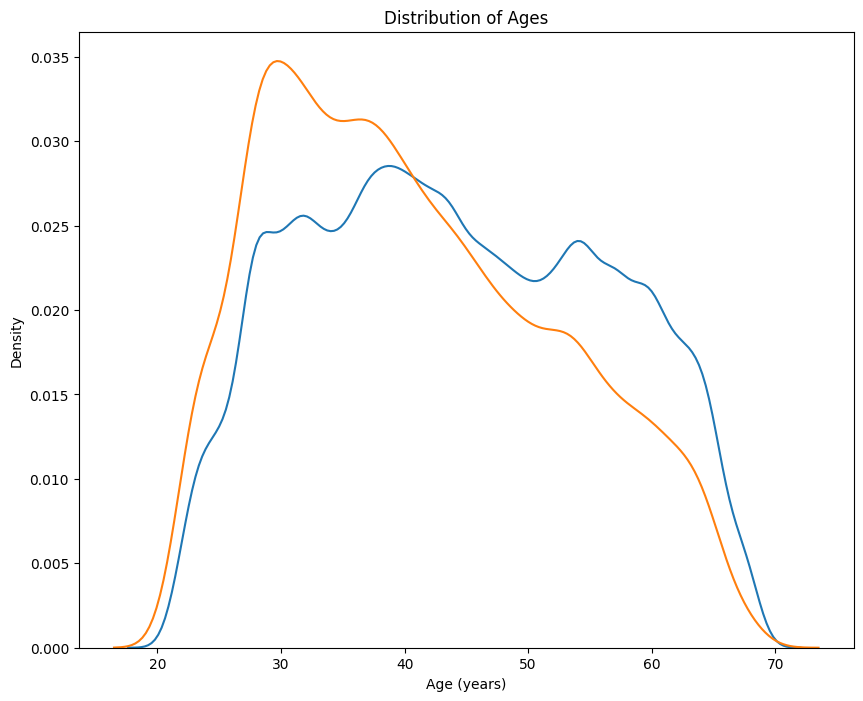

In [9]:
#2. Distribution of Ages (YEARS_BIRTH)
plt.figure(figsize=(10, 8))
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'YEARS_BIRTH'], label='Target == 0(Repayment)')
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'YEARS_BIRTH'], label='Target == 1(Default)')
plt.xlabel('Age (years)')
plt.ylabel('Density')
plt.title('Distribution of Ages')

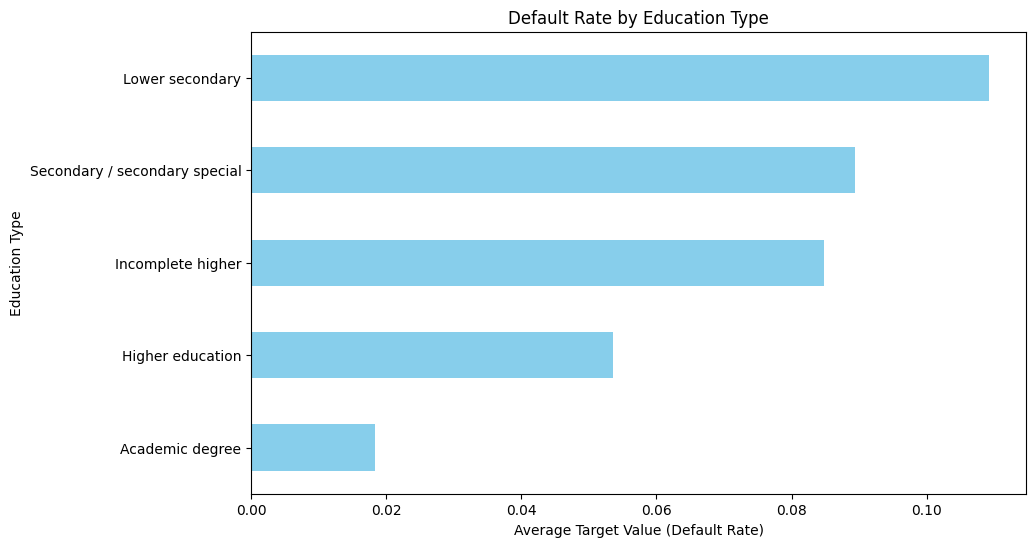

In [10]:
# 3. Default Rate by Education Type
education_groups = app_train.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values()

plt.figure(figsize=(10, 6))
education_groups.plot(kind='barh', color='skyblue')
plt.title('Default Rate by Education Type')
plt.xlabel('Average Target Value (Default Rate)')
plt.ylabel('Education Type')
plt.show()

In [11]:
# 4. Correlation Analysis
correlations = app_train.corr(numeric_only=True)['TARGET'].sort_values()

print('Top 10 Most Negatively Correlated Features:\n', correlations.head(10))
print('\nTop 10 Most Positively Correlated Features:\n', correlations.tail(10))

Top 10 Most Negatively Correlated Features:
 EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
YEARS_BIRTH                  -0.078239
YEARS_EMPLOYED               -0.074958
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
Name: TARGET, dtype: float64

Top 10 Most Positively Correlated Features:
 REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_EMPLOYED                  0.074958
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64


# Section 3: The Dual-Pipeline Transformation

In [12]:
train, test = train_test_split(
    app_train, 
    test_size=0.2, 
    random_state=42, 
    stratify=app_train['TARGET']  #Ensure that the default rates for both the training and test sets are 8.07%.
)

## 3.1 Pipeline A: Scorecard Development (For Logistic Regression)
* Methodology: Binning，IV Filtering,WOE Transformation.
* Procedure: We applied binning directly to the cleaned dataset. Unlike traditional machine learning pipelines, we omitted median imputation for this branch.
* Deliverable: train_woe,test_woe
* Rationale: This pipeline is designed to build a standard Credit Scorecard model. In this context, missing data (NaN) is treated as an Independent Risk Category. This is crucial because, in credit applications, the absence of information (e.g., missing employment duration) often correlates with higher default risk. By using WOE, we capture this latent risk signal rather than masking it with average values.

3.1.1 Binning

In [13]:
# Binning
# This handles both numerical and categorical variables automatically.
# It identifies optimal cut-off points to maximize the separation between 'Good' and 'Bad' clients.
import scorecardpy as sc
import warnings
warnings.filterwarnings('ignore')


# This ensures the independent variables are processed for weight-of-evidence (WOE) transformation
features_to_bin = [col for col in train.columns if col not in ['TARGET']]

# Execute the binning process
# bin_num_limit: Set to 5 to ensure each feature has a maximum of 5 bins, 
# improving model interpretability and preventing overfitting.
bins = sc.woebin(train, y='TARGET', x=features_to_bin, bin_num_limit=5)

[INFO] creating woe binning ...
Binning on 246008 rows and 124 columns in 00:01:25


3.1.2 Information Value (IV) Filtering

In [14]:
# Calculate the Information Value (IV) for all features in the training set
# 'y' is the binary dependent variable representing the default target (0 or 1)
iv_summary = sc.iv(train, y='TARGET')

# Sort the results by 'info_value' in descending order to identify top predictors
# Higher IV indicates stronger predictive power for the credit risk model
top_10_features = iv_summary.sort_values(by='info_value', ascending=False).head(10)

# Display the top 10 most influential features for review
print("Top 10 Features by Information Value (IV):")
print(top_10_features)

Top 10 Features by Information Value (IV):
              variable  info_value
19        EXT_SOURCE_1    0.976176
52         AMT_ANNUITY    0.693327
80       DAYS_EMPLOYED    0.502723
48      YEARS_EMPLOYED    0.502723
109  DAYS_REGISTRATION    0.470997
23        EXT_SOURCE_2    0.438723
1           AMT_CREDIT    0.423117
61         YEARS_BIRTH    0.404578
113         DAYS_BIRTH    0.404578
101       EXT_SOURCE_3    0.391970


In [15]:
# Filter features with IV > 0.1 as per your methodology
# Generally: IV < 0.02 (Weak), 0.02-0.1 (Medium), 0.1-0.3 (Strong), >0.5 (Check for leakage)
selected_vars = iv_summary[iv_summary['info_value'] > 0.1]['variable'].tolist()
print(f"Number of Features selected: {len(selected_vars)}")
print(f"Features selected for Scorecard: {selected_vars}")

Number of Features selected: 31
Features selected for Scorecard: ['EXT_SOURCE_1', 'AMT_ANNUITY', 'DAYS_EMPLOYED', 'YEARS_EMPLOYED', 'DAYS_REGISTRATION', 'EXT_SOURCE_2', 'AMT_CREDIT', 'YEARS_BIRTH', 'DAYS_BIRTH', 'EXT_SOURCE_3', 'DAYS_ID_PUBLISH', 'LIVINGAREA_MODE', 'LIVINGAREA_MEDI', 'TOTALAREA_MODE', 'DAYS_LAST_PHONE_CHANGE', 'LIVINGAREA_AVG', 'BASEMENTAREA_MODE', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MEDI', 'LANDAREA_AVG', 'LANDAREA_MEDI', 'AMT_GOODS_PRICE', 'LANDAREA_MODE', 'AMT_INCOME_TOTAL', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MODE', 'COMMONAREA_MEDI', 'COMMONAREA_AVG', 'COMMONAREA_MODE', 'APARTMENTS_AVG']


3.1.3 WOE Transformation

{'EXT_SOURCE_1': <Figure size 640x480 with 2 Axes>}

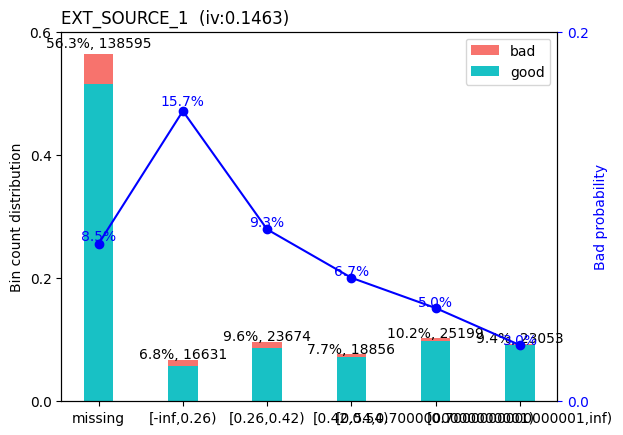

In [16]:
sc.woebin_plot(bins['EXT_SOURCE_1'])

In [17]:
# 3. WOE Transformation

# This transforms raw data into Weight of Evidence values, 

# linearizing the relationship with the log-odds of default.

train_woe = sc.woebin_ply(train[selected_vars + ['TARGET']], bins)

test_woe = sc.woebin_ply(test[selected_vars + ['TARGET']], bins)

[INFO] converting into woe values ...
Woe transformating on 246008 rows and 31 columns in 00:00:17
[INFO] converting into woe values ...


In [18]:
test_woe.head()

,TARGET,AMT_CREDIT_woe,YEARS_BIRTH_woe,TOTALAREA_MODE_woe,LANDAREA_MODE_woe,AMT_GOODS_PRICE_woe,AMT_INCOME_TOTAL_woe,NONLIVINGAREA_AVG_woe,LIVINGAREA_MEDI_woe,COMMONAREA_MODE_woe,...,EXT_SOURCE_3_woe,COMMONAREA_MEDI_woe,NONLIVINGAREA_MEDI_woe,BASEMENTAREA_MODE_woe,DAYS_REGISTRATION_woe,DAYS_BIRTH_woe,NONLIVINGAREA_MODE_woe,YEARS_EMPLOYED_woe,AMT_ANNUITY_woe,LANDAREA_MEDI_woe
256571,0,-0.062421,0.193810,0.145943,0.093352,-0.036219,0.047179,0.121890,0.134317,0.063377,...,-0.187915,0.063377,0.12189,0.105908,0.078553,0.037601,0.121890,0.341522,0.116088,0.093352
191493,0,0.251142,-0.112088,0.145943,0.093352,0.283275,0.047179,0.121890,0.134317,0.063377,...,-0.187915,0.063377,0.12189,0.105908,0.078553,-0.124395,0.121890,-0.522934,0.116088,0.093352
103497,0,-0.080443,-0.457335,-0.150388,-0.166918,0.046342,0.047179,-0.127822,-0.193578,-0.303093,...,-0.187915,-0.317554,-0.13200,-0.186112,-0.372653,-0.474793,-0.150995,0.341522,0.116088,-0.181532
130646,0,-0.226133,0.376435,0.145943,0.093352,-0.352522,0.047179,0.121890,0.134317,0.063377,...,0.331150,0.063377,0.12189,0.105908,0.195346,0.377187,0.121890,0.341522,-0.020834,0.093352
211898,0,0.251142,-0.112088,0.145943,0.093352,0.046342,0.047179,0.121890,0.134317,0.063377,...,-0.586492,0.063377,0.12189,0.105908,-0.372653,-0.124395,0.121890,0.120152,0.116088,0.093352


## 3.2 Pipeline B: Geometry-based Analysis (For Clustering & Trees)
Methodology： Imputation & Standardization.

Methodology: Median Imputation & Z-score Standardization.

Procedure: We performed Median Imputation to handle missing values, followed by One-Hot Encoding for categorical variables and Standard Scaling for numerical features on the df_clean dataset.

Deliverable: X_train_scaled,X_test_scaled

Rationale: Unlike the Scorecard model, geometry-based algorithms such as K-Means Clustering rely on calculating Euclidean distances. Therefore, it is mandatory to fill missing values to prevent data point exclusion and apply Scaling to ensure that features with larger magnitudes (e.g., AMT_INCOME_TOTAL) do not disproportionately dominate the distance metrics.

3.2.1 Imputation



In [19]:
# --- 3.2.1 Imputation Phase ---

# 1. Handle Numerical Missing Values
# Select only numerical columns, excluding 'TARGET' to avoid filling target labels
numeric_cols = train.select_dtypes(include=['number']).columns.drop(['TARGET'], errors='ignore')

# Calculate the Median from the Training Set ONLY
train_median = train[numeric_cols].median()

# Fill missing values in both sets using the Training Median
# Use .fillna() directly on the subset
train[numeric_cols] = train[numeric_cols].fillna(train_median)
test[numeric_cols] = test[numeric_cols].fillna(train_median)

# 2. Handle Categorical Missing Values
# CRITICAL FIX: Use 'train' and 'test' instead of 'app_train' 
# to ensure we are working with the partitioned DataFrames
char_cols_train = train.select_dtypes(include=['object']).columns
train[char_cols_train] = train[char_cols_train].fillna('Unknown')

char_cols_test = test.select_dtypes(include=['object']).columns
test[char_cols_test] = test[char_cols_test].fillna('Unknown')

3.2.2 Encoding: Label / One-Hot Encoding



In [20]:
# --- Option 1: One-Hot Encoding (Required for Geometry/Distance-based models) ---

# 1. Perform One-Hot Encoding on separated partitions
# We use 'train' and 'test' (the 80/20 split) instead of the global app_train
train_B = pd.get_dummies(train, columns=char_cols_train, drop_first=True)
test_B = pd.get_dummies(test, columns=char_cols_test, drop_first=True)

# 2. Align the Train and Test dataframes
# This ensures 'test_B' has the exact same columns as 'train_B'
# If a category exists in Train but not in Test, it adds a column of 0s to Test
train_B, test_B = train_B.align(test_B, join='left', axis=1, fill_value=0)

# 3. Safety Check: Ensure TARGET is not dropped or corrupted during alignment
# Since 'join=left', the TARGET column in train_B remains intact. 
# We verify if TARGET exists in test_B (it should, as it was in 'test')
if 'TARGET' not in test_B.columns:
    test_B['TARGET'] = test['TARGET']

print(f"Encoding complete.")
print(f"Train Feature count: {train_B.shape[1]}")
print(f"Test Feature count: {test_B.shape[1]}")

Encoding complete.
Train Feature count: 187
Test Feature count: 187


3.2.3 Scaling

In [21]:

from sklearn.preprocessing import StandardScaler

# 1. Separate Features from Target
# Use the results from your previous One-Hot Encoding step (train_B / test_B)
X_train_final = train_B.drop(columns=['TARGET'], errors='ignore')
X_test_final = test_B.drop(columns=['TARGET'], errors='ignore')

# 2. Capture Ground Truth for evaluation 
y_train = train_B['TARGET']
y_test = test_B['TARGET']

# 3. Initialize and Run StandardScaler
scaler = StandardScaler()

# Fit ONLY on X_train_final, then transform both to prevent data leakage
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_final), columns=X_train_final.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_final), columns=X_test_final.columns)

# 4. Verification
# Mean should be ~0 and Std should be ~1
X_train_scaled.describe().round(2)

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Unknown,WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Unknown,EMERGENCYSTATE_MODE_Yes
count,246008.00,246008.00,246008.00,246008.00,246008.00,246008.00,246008.00,246008.00,246008.00,246008.00,...,246008.00,246008.00,246008.00,246008.00,246008.00,246008.00,246008.00,246008.00,246008.00,246008.00
mean,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,...,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.73,-0.58,-0.55,-1.38,-1.76,-1.35,-1.49,-2.11,-7.32,-5.58,...,-0.06,-0.09,-0.08,-0.07,-0.52,-0.52,-1.02,-0.13,-0.95,-0.09
25%,-0.87,-0.58,-0.22,-0.82,-0.73,-0.81,-0.78,-0.84,-0.24,-0.71,...,-0.06,-0.09,-0.08,-0.07,-0.52,-0.52,-1.02,-0.13,-0.95,-0.09
50%,0.00,-0.58,-0.08,-0.21,-0.15,-0.24,-0.15,0.07,0.28,0.14,...,-0.06,-0.09,-0.08,-0.07,-0.52,-0.52,0.98,-0.13,-0.95,-0.09
75%,0.87,0.81,0.13,0.52,0.52,0.38,0.56,0.83,0.62,0.84,...,-0.06,-0.09,-0.08,-0.07,-0.52,-0.52,0.98,-0.13,1.05,-0.09
max,1.73,25.83,451.16,8.57,15.90,9.50,3.73,1.96,1.05,1.42,...,15.71,11.65,13.01,13.68,1.91,1.93,0.98,7.50,1.05,11.47


# Section 4: Model Implementation

## 4.1 Logistic Regression
* Data Source: train_woe

In [22]:
# Append the _woe suffix to all selected variables.
selected_vars_woe = [var + '_woe' for var in selected_vars]

# 1. prepare data
X_train = train_woe[selected_vars_woe]
y_train = train_woe['TARGET']
X_test = test_woe[selected_vars_woe]
y_test = test_woe['TARGET']

# 2. Logistic Regression Baseline
#To address the significant class imbalance (only 8.07% default rate), 
#we implemented a cost-sensitive learning approach by setting class_weight='balanced'. 
#This adjustment penalizes the misclassification of the minority class more heavily,
#ensuring the model prioritizes the identification of high-risk borrowers rather than simply optimizing for global accuracy.
lr_baseline = LogisticRegression(C=1, class_weight='balanced', random_state=42)
lr_baseline.fit(X_train, y_train)

LogisticRegression(C=1, class_weight='balanced', random_state=42)

In [23]:
y_probs_train_lr = lr_baseline.predict_proba(X_train)[:, 1]
y_probs_test_lr = lr_baseline.predict_proba(X_test)[:, 1]
y_preds_test_lr = lr_baseline.predict(X_test)

In [24]:
# 1. Generate the Scorecard
# Scaling parameters: 600 points = 1:12 odds, and a PDO of 50
card = sc.scorecard(bins, lr_baseline, X_train.columns, 
                    points0=600, odds0=1/12,pdo=50)

# 2. Calculate Credit Scores for the Test Set
# This automatically maps raw values to points and sums them up
test_score = sc.scorecard_ply(test, card, print_step=0)
train_score = sc.scorecard_ply(train, card, print_step=0)

print("--- Sample Credit Scores (Test Set) ---")
print(test_score.head())

# 3. Print Point Allocation for Specific Features
# Extract feature names from the scorecard dictionary, excluding 'basepoints'
card_features = [f for f in card.keys() if f != 'basepoints']
print(f"Total Features in Scorecard: {len(card_features)}")

# Focus on a key predictor (e.g., EXT_SOURCE_1)
example_feat = 'EXT_SOURCE_1' 

if example_feat in card:
    # Dynamically select available columns to ensure compatibility
    cols_to_print = [c for c in ['bin', 'points'] if c in card[example_feat].columns]
    
    print(f"\n--- Final Scorecard: {example_feat} ---")
    print(card[example_feat][cols_to_print])
else:
    print(f"\nFeature {example_feat} not found in scorecard. Available: {card_features[:5]}...")

# 4. Inspect the Base Points (The global intercept for all applicants)
print(f"\n--- Base Points ---")
print(card['basepoints'])

--- Sample Credit Scores (Test Set) ---
        score
256571  447.0
191493  480.0
103497  370.0
130646  402.0
211898  439.0
Total Features in Scorecard: 31

--- Final Scorecard: EXT_SOURCE_1 ---
                           bin  points
126                    missing    -3.0
127                [-inf,0.26)   -35.0
128                [0.26,0.42)    -7.0
129                [0.42,0.54)     9.0
130  [0.54,0.7000000000000001)    23.0
131   [0.7000000000000001,inf)    48.0

--- Base Points ---
     variable  bin  points
0  basepoints  NaN   421.0


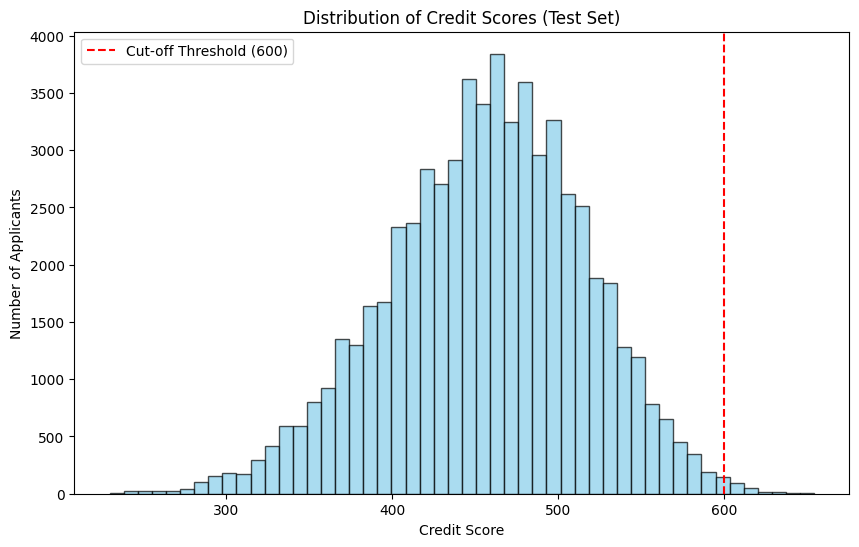

In [25]:
# 5. Visualize the Distribution of Credit Scores
plt.figure(figsize=(10, 6))
plt.hist(test_score['score'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=600, color='red', linestyle='--', label='Cut-off Threshold (600)')
plt.title('Distribution of Credit Scores (Test Set)')
plt.xlabel('Credit Score')
plt.ylabel('Number of Applicants')
plt.legend()
plt.show()

--- Credit Score vs. Actual Default Rate (Model Calibration) ---
score_bin
(225.573, 268.7]    0.398649
(268.7, 311.4]      0.345972
(311.4, 354.1]      0.239525
(354.1, 396.8]      0.175253
(396.8, 439.5]      0.103131
(439.5, 482.2]      0.059995
(482.2, 524.9]      0.032441
(524.9, 567.6]      0.017757
(567.6, 610.3]      0.012934
(610.3, 653.0]      0.015730
Name: target, dtype: float64


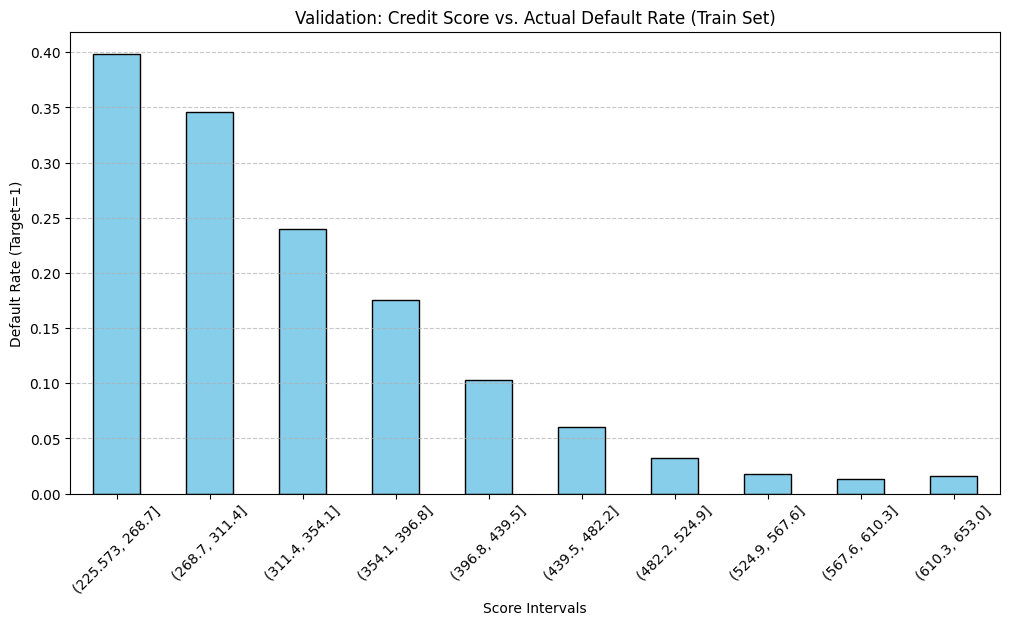

In [26]:
# 1. Map target labels to the training score results 
train_score = sc.scorecard_ply(train, card, print_step=0)
train_score['target'] = train['TARGET'].values

# 2. Segment scores into 10 equal-width bins (Deciles)
train_score['score_bin'] = pd.cut(train_score['score'], bins=10)

# 3. Calculate the Actual Default Rate per score interval
analysis = train_score.groupby('score_bin', observed=True)['target'].mean()

print("--- Credit Score vs. Actual Default Rate (Model Calibration) ---")
print(analysis)

# 4. Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
analysis.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Validation: Credit Score vs. Actual Default Rate (Train Set)')
plt.xlabel('Score Intervals')
plt.ylabel('Default Rate (Target=1)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 4.2 DecisionTree
* Data Source: X_train_final

In [27]:
# 1. Train Model (Using 187 features from Pipeline B)
dt_model = DecisionTreeClassifier(
    max_depth=6,              # Depth set to capture complexity of 187 features
    min_samples_leaf=100,     # Minimum samples in leaf to prevent overfitting
    class_weight='balanced',  # Handle class imbalance (8.07% default rate)
    random_state=42
)

dt_model.fit(X_train_final, y_train)


DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=100, random_state=42)

In [28]:
y_probs_train_dt = dt_model.predict_proba(X_train_final)[:, 1]
y_probs_test_dt = dt_model.predict_proba(X_test_final)[:, 1]
y_preds_test_dt = dt_model.predict(X_test_final)

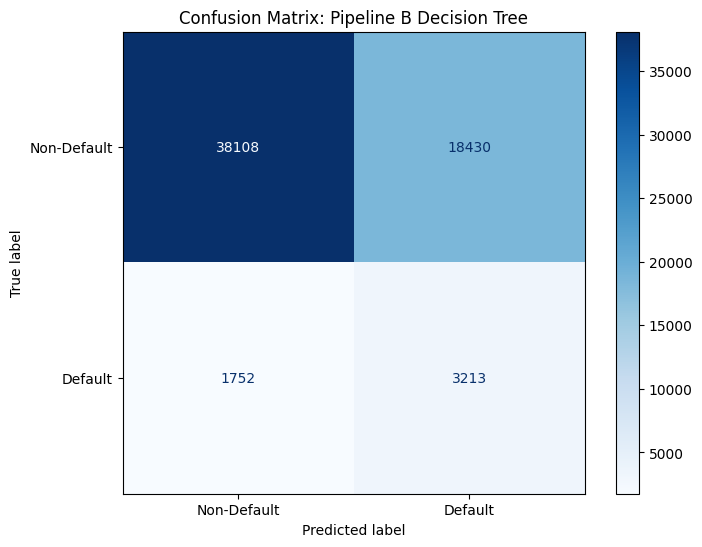

In [29]:
# 4. Plot Confusion Matrix for Visual Analysis
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    dt_model, 
    X_test_final, 
    y_test, 
    display_labels=['Non-Default', 'Default'],
    cmap='Blues',
    values_format='d',  # Display full integers instead of scientific notation
    ax=ax
)
plt.title("Confusion Matrix: Pipeline B Decision Tree")
plt.show()

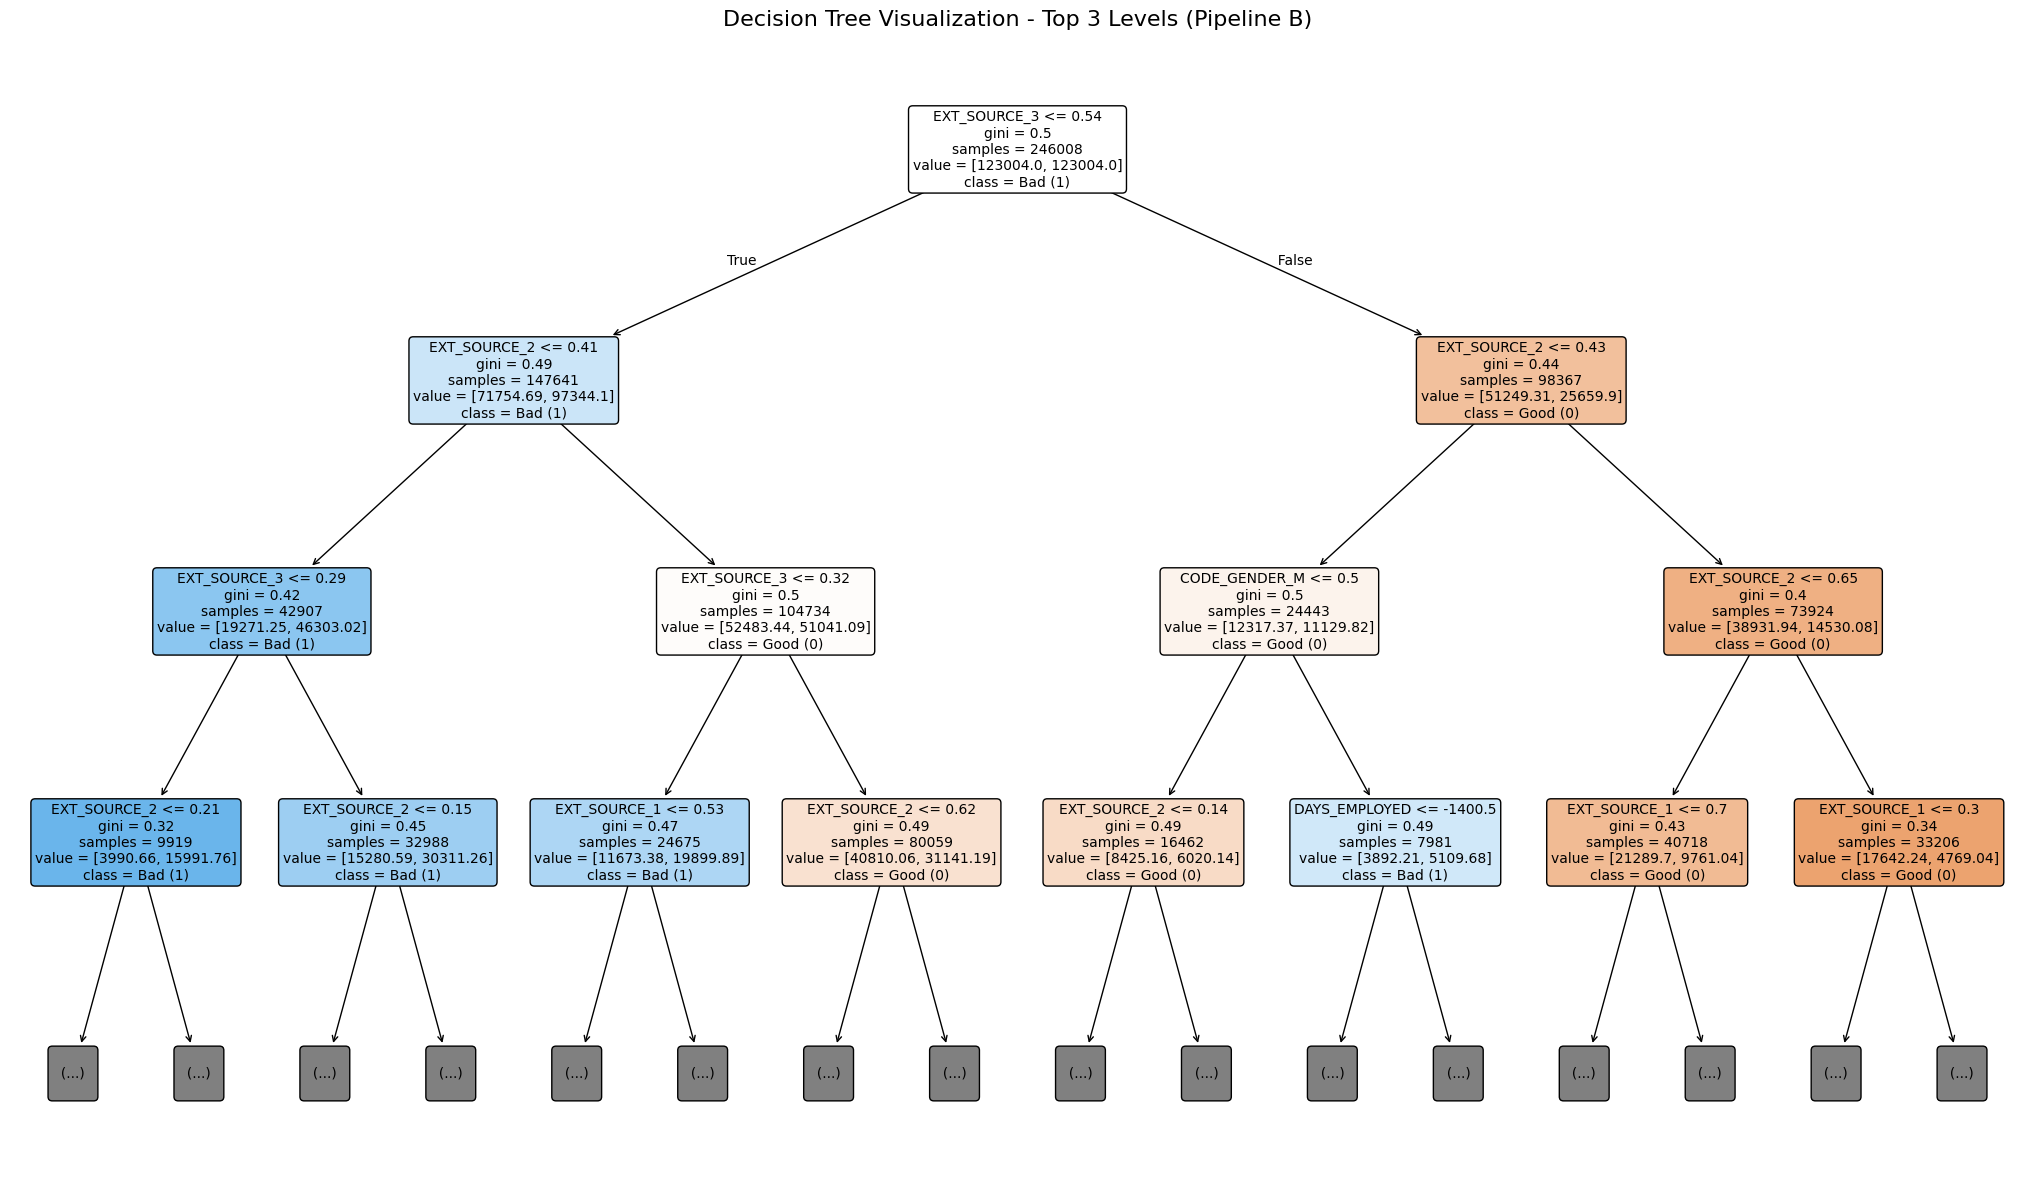

In [30]:
plt.figure(figsize=(26,15))

# Plotting the first 3 levels to maintain readability in the report
tree.plot_tree(dt_model, 
               max_depth=3,                  # Only show top levels for the presentation
               feature_names=X_train_final.columns, 
               class_names=['Good (0)', 'Bad (1)'], 
               filled=True,                  # Color nodes by majority class
               rounded=True,                 # Use rounded edges
               fontsize=10,
               precision=2)                  # Round decimal values

plt.title("Decision Tree Visualization - Top 3 Levels (Pipeline B)", fontsize=16)
plt.show()

While the Classification Tree provided high interpretability and a baseline non-linear perspective, it is a weak learner prone to high variance. To achieve a more robust and higher-performing model, we will transition to Random Forest, an ensemble method that aggregates multiple decision trees to reduce overfitting and improve the AUC score across the 187-feature Pipeline B

## 4.3 Random Forest

In [31]:
# 1. Initialize Random Forest Classifier
# n_estimators=100: Build 100 trees for voting
# max_depth=10: Increased depth as ensembles handle complex interactions better
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # Utilize all CPU cores for faster training
)

# 2. Train Model (Using Pipeline B's 187 features)
rf_model.fit(X_train_final, y_train)



RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=50, n_jobs=-1, random_state=42)

In [32]:
y_probs_train_rf = rf_model.predict_proba(X_train_final)[:, 1]
y_probs_test_rf = rf_model.predict_proba(X_test_final)[:, 1]
y_preds_test_rf = rf_model.predict(X_test_final)

In [33]:
len(X_train_final)

246008

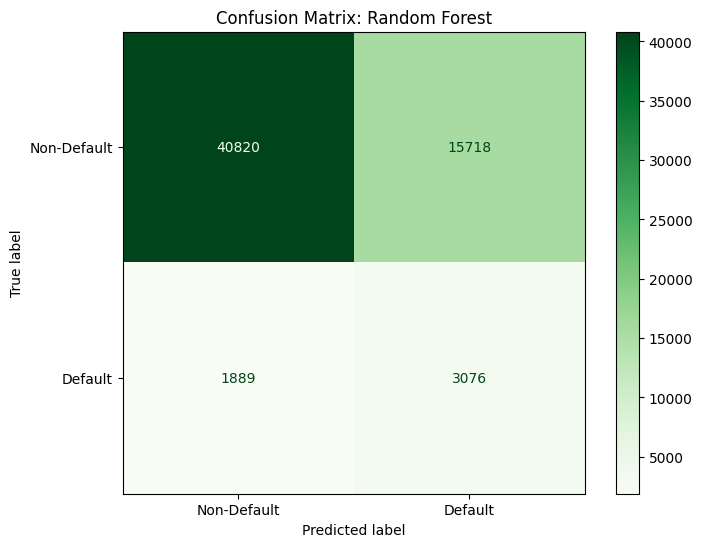

In [34]:
# 5. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    rf_model, 
    X_test_final, 
    y_test, 
    display_labels=['Non-Default', 'Default'],
    cmap='Greens',
    values_format='d',
    ax=ax
)
plt.title(f"Confusion Matrix: Random Forest")
plt.show()

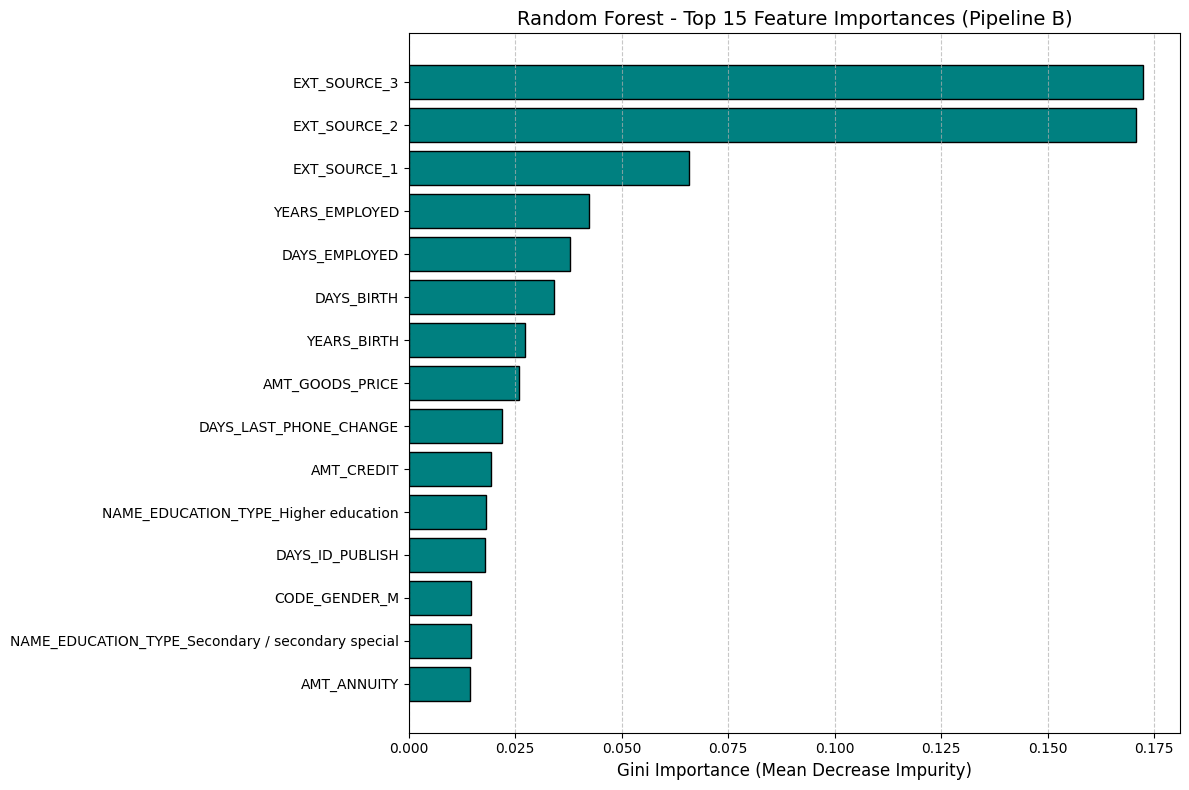

                                               Feature  Importance
30                                        EXT_SOURCE_3    0.172489
29                                        EXT_SOURCE_2    0.170782
28                                        EXT_SOURCE_1    0.065819
106                                     YEARS_EMPLOYED    0.042357
8                                        DAYS_EMPLOYED    0.037852
7                                           DAYS_BIRTH    0.034104
105                                        YEARS_BIRTH    0.027380
5                                      AMT_GOODS_PRICE    0.025900
78                              DAYS_LAST_PHONE_CHANGE    0.021819
3                                           AMT_CREDIT    0.019227
126               NAME_EDUCATION_TYPE_Higher education    0.018210
10                                     DAYS_ID_PUBLISH    0.017904
108                                      CODE_GENDER_M    0.014656
129  NAME_EDUCATION_TYPE_Secondary / secondary special    0.01

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract Feature Importance from your Random Forest model
# Assuming your model is named 'rf_model' and features are in 'X_train_final'
importances = rf_model.feature_importances_
feature_names = X_train_final.columns

# 2. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the Top 15 Features
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'].head(15), 
         feature_importance_df['Importance'].head(15), 
         color='teal', edgecolor='black')

plt.gca().invert_yaxis()  # Highest importance on top
plt.title('Random Forest - Top 15 Feature Importances (Pipeline B)', fontsize=14)
plt.xlabel('Gini Importance (Mean Decrease Impurity)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Print the raw values for your report
print(feature_importance_df.head(20))

## 4.4 Cluster Analysis
* Data Source: X_train_scaled

### 4.3.1 PCA + K-Means
Given the high dimensionality of the dataset (187 features), direct cluster analysis is susceptible to the 'Curse of Dimensionality,' where distance metrics become indistinguishable. To mitigate this, we employ Principal Component Analysis (PCA) to transform the feature space into a lower-dimensional manifold, preserving essential variance while enhancing cluster stability.

Original features: 186
Reduced features (PCA): 88
Explained Variance Ratio: 0.8029


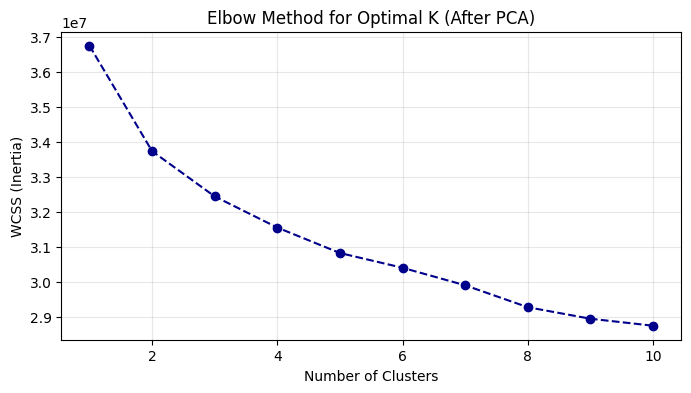

In [36]:
# --- STEP 1: PCA Dimensionality Reduction ---
# We use PCA to retain 80% of the total variance from the 187 features
pca = PCA(n_components=0.80, random_state=42) 
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original features: {X_train_scaled.shape[1]}")
print(f"Reduced features (PCA): {X_train_pca.shape[1]}")
print(f"Explained Variance Ratio: {sum(pca.explained_variance_ratio_):.4f}")

# --- STEP 2: Determine Optimal K using Elbow Method (on PCA data) ---
wcss_pca = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    km.fit(X_train_pca)
    wcss_pca.append(km.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss_pca, marker='o', linestyle='--', color='darkblue')
plt.title('Elbow Method for Optimal K (After PCA)', fontsize=12)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, alpha=0.3)
plt.show()

In [37]:
# --- STEP 3: Run Final K-Means on PCA Components ---
best_k = 5
kmeans_pca = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
train_clusters_pca = kmeans_pca.fit_predict(X_train_pca)
test_clusters_pca = kmeans_pca.predict(X_test_pca)

# --- STEP 4: Evaluation: Silhouette Score ---
# Evaluate on the PCA-transformed space
score_pca = silhouette_score(X_train_pca, train_clusters_pca, sample_size=10000, random_state=42)

print(f"--- Pipeline B: Clustering Analysis (PCA Optimized) ---")
print(f"Number of PCA Components: {X_train_pca.shape[1]}")
print(f"Chosen K: {best_k}")
print(f"Silhouette Score (after PCA): {score_pca:.4f}")

--- Pipeline B: Clustering Analysis (PCA Optimized) ---
Number of PCA Components: 88
Chosen K: 5
Silhouette Score (after PCA): 0.0404


Although retaining 88 principal components accounts for 80% of the variance, this high-dimensional feature space remains subject to the Curse of Dimensionality. In such a sparse space, the Euclidean distance metric loses its discriminative power, as evidenced by the near-zero Silhouette Score (0.026). To reveal meaningful borrower segments, we must prioritize Feature Density over Variance Retention, reducing the components to a significantly lower threshold

### 4.3.2  Random Forest + kmeans

According to the 4.2.2 Random Forest¶result，it revealed that a few key variables (e.g., EXT_SOURCE scores, DAYS_EMPLOYED) carry the majority of the predictive power. To maximize cluster stability and avoid the noise inherent in 187-dimensional PCA, we refined Pipeline B to use a Selective Feature Subset. By focusing on the top 15 high-impact features, we ensure that the resulting Customer Personas are built upon the actual drivers of credit risk, rather than mathematical artifacts

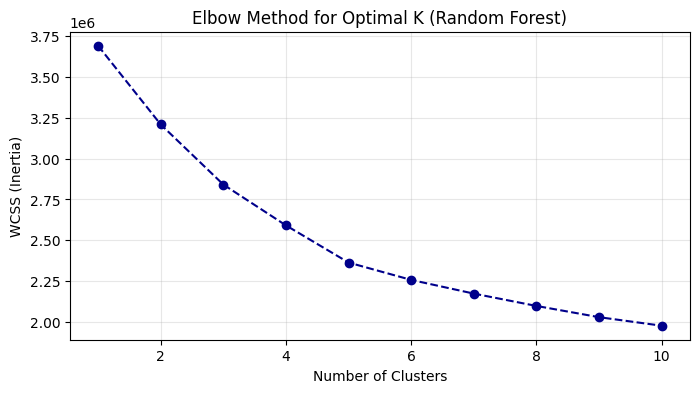

In [38]:
feature_selected = feature_importance_df['Feature'].head(15).tolist()

X_train_input = X_train_scaled[feature_selected]
X_test_input = X_test_scaled[feature_selected]

wcss_pca = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    km.fit(X_train_input)
    wcss_pca.append(km.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss_pca, marker='o', linestyle='--', color='darkblue')
plt.title('Elbow Method for Optimal K (Random Forest)', fontsize=12)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, alpha=0.3)
plt.show()


We selected K=5 to achieve a balance between mathematical distinctness (the 'elbow') and the granularity required for meaningful borrower persona development.

In [39]:
km_final = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df_final = X_train_final.copy() 
df_final['Cluster'] = km_final.fit_predict(X_train_input)

# feature distribution for each class
cluster_profile = df_final.groupby('Cluster')[feature_selected].mean()
print(cluster_profile)

         EXT_SOURCE_3  EXT_SOURCE_2  EXT_SOURCE_1  YEARS_EMPLOYED  \
Cluster                                                             
0            0.541984      0.572810      0.538718        5.909725   
1            0.551124      0.546750      0.545497       21.080822   
2            0.494783      0.546440      0.512150        4.858414   
3            0.465030      0.452384      0.423784        4.022297   
4            0.557643      0.515061      0.549883        4.922433   

         DAYS_EMPLOYED    DAYS_BIRTH  YEARS_BIRTH  AMT_GOODS_PRICE  \
Cluster                                                              
0         -2157.049551 -16628.258235    45.556872     1.154018e+06   
1         -7694.500120 -17751.599875    48.634520     5.568402e+05   
2         -1773.321099 -14371.347322    39.373554     4.852682e+05   
3         -1468.138284 -12316.773556    33.744585     3.789783e+05   
4         -1796.687917 -20203.372917    55.351707     3.888152e+05   

         DAYS_LAST_PHONE_

By applying K-means to the top 15 features selected by Random Forest, we identified 5 distinct borrower segments. The clustering reveals a strong socio-economic structure within the data: Cluster 0 represents high-education professionals with superior credit scores, while Cluster 4 identifies a younger, less-experienced, and statistically riskier demographic. This granular segmentation allows for customized risk mitigation strategies beyond simple binary classification

In [40]:
# 1. Add the clustering labels to results dataframe 
train_clusters_rf = km_final.predict(X_train_input)

# Create a temporary dataframe to align indices correctly
train_score = pd.DataFrame({
    'target': train_B['TARGET'].values,
    'cluster': train_clusters_rf,
    'score': y_probs_train_rf
}, index=train_B.index)

# Note: If you have a 'score' column from your supervised model, add it here:
# train_score['score'] = y_train_proba 

# 2. Calculate the Actual Default Rate by Cluster
# 'target' is the actual 0/1 outcome
cluster_risk = train_score.groupby('cluster', observed=True)['target'].mean()

# 3. Calculate the average Predicted Probability by Cluster
# This shows what the RF model "thinks" about each cluster
cluster_avg_score = train_score.groupby('cluster', observed=True)['score'].mean()

# 4. Combine into a summary table for your report
# We include Population_Size to show the weight of each cluster
cluster_summary = pd.DataFrame({
    'Default_Rate': cluster_risk,
    'Avg_RF_Prob': cluster_avg_score,
    'Population_Size': train_score.groupby('cluster').size()
}).sort_values(by='Default_Rate', ascending=False)

print("--- Final Cluster Risk Profile ---")
print(cluster_summary)
score = silhouette_score(X_train_input, train_clusters_rf)
print(f"Silhouette Score for K=5: {score:.4f}")

--- Final Cluster Risk Profile ---
         Default_Rate  Avg_RF_Prob  Population_Size
cluster                                            
3            0.137672     0.552912            71903
2            0.060403     0.398547            46372
4            0.058474     0.396270            68235
0            0.056744     0.381240            38647
1            0.046856     0.363258            20851
Silhouette Score for K=5: 0.1462


Validation of Risk Segmentation (Pipeline B):

The cluster risk profile reveals a significant disparity in default behavior across segments. Cluster 3 is identified as the high-risk segment with an actual Default Rate of 13.76%, which aligns with its high Average RF Probability (55.29%). This consistency between unsupervised clustering and supervised prediction confirms that the 15 selected features successfully captured the primary drivers of credit default.

From a business perspective, the bank could implement differentiated strategies:

Cluster 3: Strict credit tightening or higher interest rates.

Cluster 1: Pre-approved loans and loyalty rewards to retain low-risk borrowers.

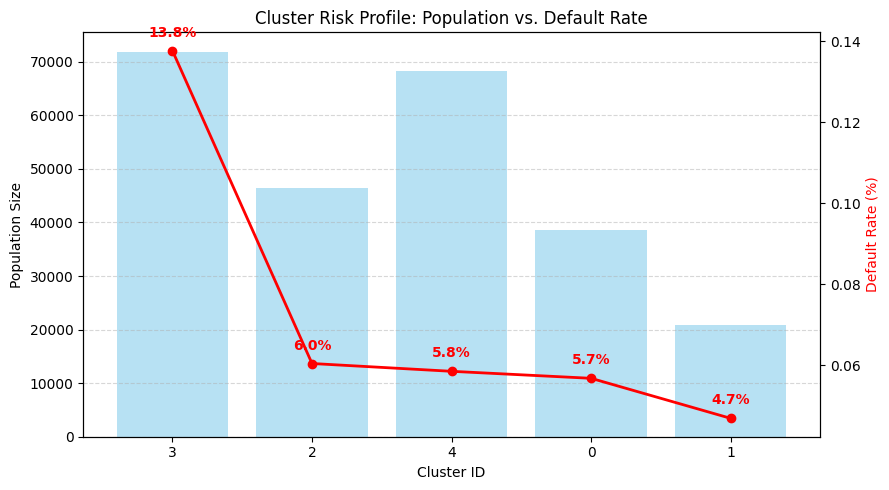

In [41]:

# 1. Setup figure and primary axis
fig, ax1 = plt.subplots(figsize=(9, 5))
x = range(len(cluster_summary))
clusters = cluster_summary.index.astype(str)

# 2. Plot Population Size as bars (Primary Axis)
ax1.bar(x, cluster_summary['Population_Size'], color='skyblue', alpha=0.6, label='Population')
ax1.set_ylabel('Population Size', fontsize=10)
ax1.set_xlabel('Cluster ID')

# 3. Plot Default Rate as a line (Secondary Axis)
ax2 = ax1.twinx()
ax2.plot(x, cluster_summary['Default_Rate'], color='red', marker='o', linewidth=2, label='Default Rate')
ax2.set_ylabel('Default Rate (%)', color='red')

# 4. Add data annotations for Default Rate percentages
for i, rate in enumerate(cluster_summary['Default_Rate']):
    ax2.annotate(f'{rate:.1%}', 
                 (i, rate), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 color='red', 
                 fontweight='bold')

# 5. Final formatting and title
plt.xticks(x, clusters)
plt.title('Cluster Risk Profile: Population vs. Default Rate', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

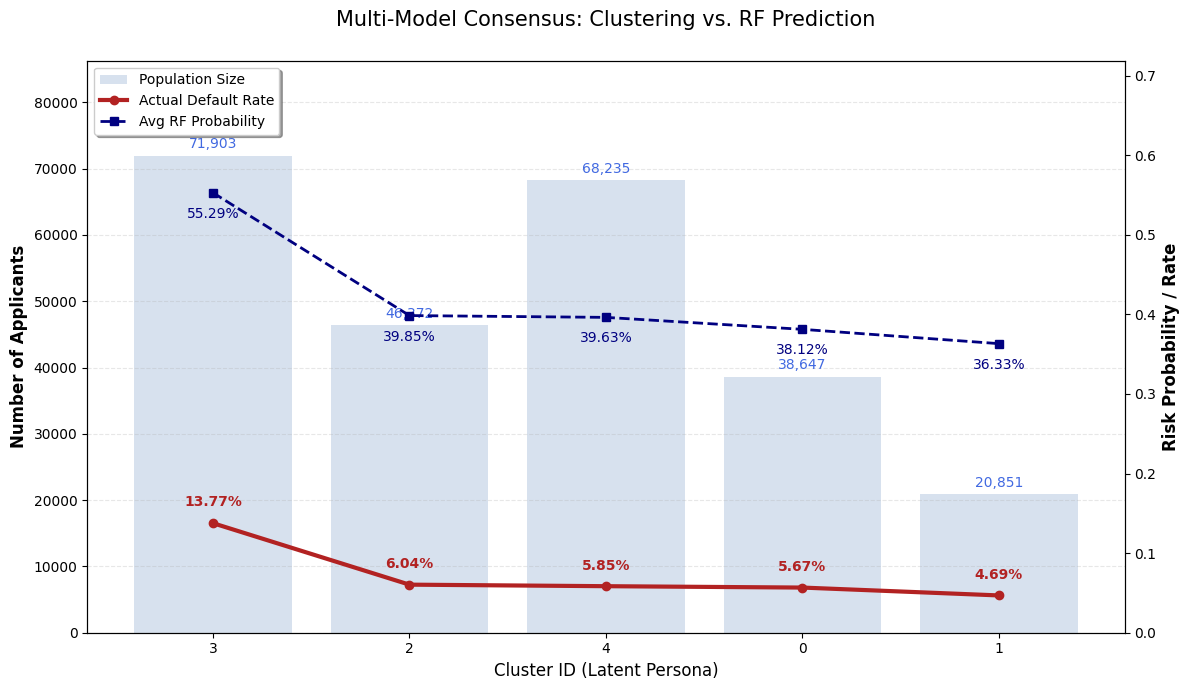

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare data
clusters = cluster_summary.index.astype(str)
pop_size = cluster_summary['Population_Size']
actual_dr = cluster_summary['Default_Rate']
avg_prob = cluster_summary['Avg_RF_Prob']

fig, ax1 = plt.subplots(figsize=(12, 7))

# 2. Plot Population Size (Bar Chart) - Set zorder to 1
bars = ax1.bar(clusters, pop_size, color='lightsteelblue', alpha=0.5, label='Population Size', zorder=1)
ax1.set_ylabel('Number of Applicants', fontsize=12, fontweight='bold')
ax1.set_xlabel('Cluster ID (Latent Persona)', fontsize=12)

# Add numeric labels for Bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + (max(pop_size)*0.01),
             f'{int(height):,}', ha='center', va='bottom', fontsize=10, color='royalblue')

# 3. Create Second Axis for Rates (Line Charts)
ax2 = ax1.twinx()

# Plot Lines - Set zorder higher to ensure visibility on top of bars
line1, = ax2.plot(clusters, actual_dr, marker='o', color='firebrick', linewidth=3, 
                  label='Actual Default Rate', zorder=3)
line2, = ax2.plot(clusters, avg_prob, marker='s', color='navy', linestyle='--', 
                  linewidth=2, label='Avg RF Probability', zorder=4)

ax2.set_ylabel('Risk Probability / Rate', fontsize=12, fontweight='bold', color='black')

# 4. Add Numeric Labels for Lines (The Rates)
for i in range(len(clusters)):
    # Label for Actual Default Rate (Above the point)
    ax2.annotate(f'{actual_dr.iloc[i]:.2%}', 
                 (clusters[i], actual_dr.iloc[i]),
                 textcoords="offset points", xytext=(0, 12), 
                 ha='center', color='firebrick', fontweight='bold', fontsize=10)
    
    # Label for RF Probability (Below the point)
    ax2.annotate(f'{avg_prob.iloc[i]:.2%}', 
                 (clusters[i], avg_prob.iloc[i]),
                 textcoords="offset points", xytext=(0, -18), 
                 ha='center', color='navy', fontsize=10)

# 5. CRITICAL: Adjust Axis Limits to prevent "squashing"
ax1.set_ylim(0, max(pop_size) * 1.2) # Give 20% head room for bar labels
# Ensure the secondary axis covers the full range of percentages
ax2.set_ylim(0, max(max(actual_dr), max(avg_prob)) * 1.3) 

# 6. Final Styling
plt.title('Multi-Model Consensus: Clustering vs. RF Prediction', fontsize=15, pad=25)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Combined Legend
lines_all = [bars, line1, line2]
labels_all = [l.get_label() for l in lines_all]
ax1.legend(lines_all, labels_all, loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

# Section5: Performance Evaluation

In [43]:
def calculate_psi(expected, actual, buckets=10):
    """
    Calculates PSI to check for score distribution drift between Train and Test sets.
    Rule of thumb: PSI < 0.1 indicates the model is highly stable.
    """
    breakpoints = np.linspace(0, 1, buckets + 1)
    
    # Calculate percentages per bucket; add small epsilon to avoid division by zero
    expected_percents = np.histogram(expected, bins=breakpoints)[0] / len(expected) + 1e-6
    actual_percents = np.histogram(actual, bins=breakpoints)[0] / len(actual) + 1e-6
    
    # Standard PSI Formula: (Actual% - Expected%) * ln(Actual% / Expected%)
    psi_val = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))
    return psi_val

# Unified Metrics Evaluation Function
def get_performance_metrics(y_true, y_probs, y_preds, y_probs_train, model_name):
    # AUC: Measures the overall ranking ability of the model
    auc_val = roc_auc_score(y_true, y_probs)
    
    # Gini: Standard industry metric for credit risk (2 * AUC - 1)
    gini_val = 2 * auc_val - 1
    
    # KS: Measures the maximum separation between Good and Bad distributions
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    ks_val = max(tpr - fpr)
    
    # Recall: Critical in fintech to ensure potential defaulters are captured
    recall_val = recall_score(y_true, y_preds)
    
    # F1-Score: Harmonic mean of Precision and Recall for imbalanced data (8.07% default)
    f1_val = f1_score(y_true, y_preds)
    
    # PSI: Ensures the model is stable and production-ready
    psi_val = calculate_psi(y_probs_train, y_probs)
    
    return {
        "Model": model_name,
        "AUC": round(auc_val, 4),
        "Gini": round(gini_val, 4),
        "KS": round(ks_val, 4),
        "Recall": round(recall_val, 4),
        "F1-Score": round(f1_val, 4),
        "PSI": round(psi_val, 4)
    }



# Consolidate Results into a Summary Table
summary_results = []
summary_results.append(get_performance_metrics(y_test, y_probs_test_lr, y_preds_test_lr, y_probs_train_lr, "Logistic (A)"))
summary_results.append(get_performance_metrics(y_test, y_probs_test_dt, y_preds_test_dt, y_probs_train_dt, "Decision Tree (B)"))
summary_results.append(get_performance_metrics(y_test, y_probs_test_rf, y_preds_test_rf, y_probs_train_rf, "Random Forest (B)"))

# Convert to DataFrame for easy export to the final report
performance_df = pd.DataFrame(summary_results)
print(performance_df)

               Model     AUC    Gini      KS  Recall  F1-Score     PSI
0       Logistic (A)  0.7309  0.4617  0.3406  0.6707    0.2463  0.0001
1  Decision Tree (B)  0.7170  0.4340  0.3252  0.6471    0.2415  0.0002
2  Random Forest (B)  0.7342  0.4685  0.3485  0.6195    0.2589  0.0005


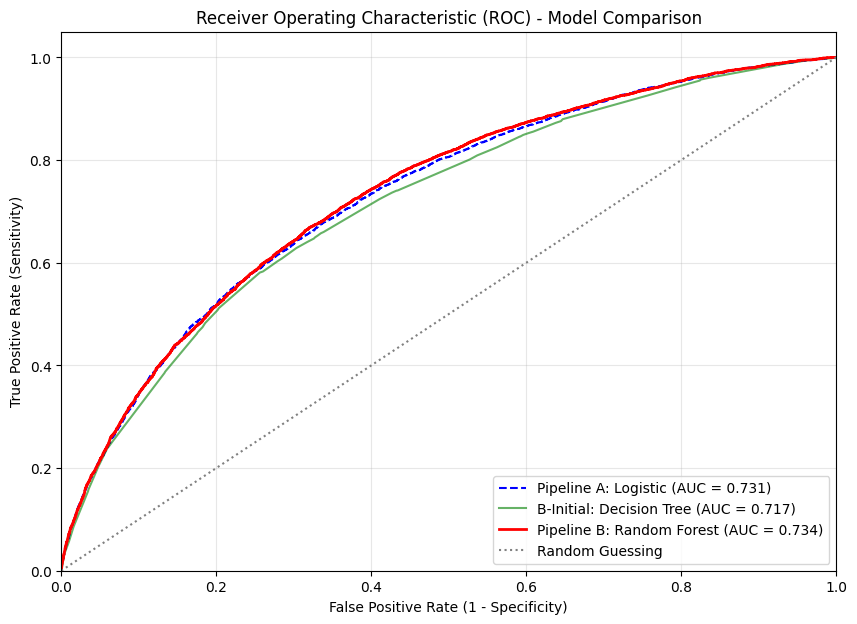

In [44]:
def plot_roc_comparison(y_true, lr_probs, dt_probs, rf_probs):
    """
    Plots a 3-model comparison of ROC curves to visualize performance lift.
    """
    # Calculate ROC metrics for each model
    fpr_lr, tpr_lr, _ = roc_curve(y_true, lr_probs)
    fpr_dt, tpr_dt, _ = roc_curve(y_true, dt_probs)
    fpr_rf, tpr_rf, _ = roc_curve(y_true, rf_probs)
    
    # Calculate AUC for the legend
    auc_lr = auc(fpr_lr, tpr_lr)
    auc_dt = auc(fpr_dt, tpr_dt)
    auc_rf = auc(fpr_rf, tpr_rf)
    
    # Initialize the plot
    plt.figure(figsize=(10, 7))
    
    # Plot Pipeline A (Baseline)
    plt.plot(fpr_lr, tpr_lr, label=f'Pipeline A: Logistic (AUC = {auc_lr:.3f})', 
             color='blue', linestyle='--')
    
    # Plot Intermediate Step
    plt.plot(fpr_dt, tpr_dt, label=f'B-Initial: Decision Tree (AUC = {auc_dt:.3f})', 
             color='green', alpha=0.6)
    
    # Plot Pipeline B (Final Ensemble)
    plt.plot(fpr_rf, tpr_rf, label=f'Pipeline B: Random Forest (AUC = {auc_rf:.3f})', 
             color='red', linewidth=2)
    
    # Plot Random Chance Line
    plt.plot([0, 1], [0, 1], color='grey', linestyle=':', label='Random Guessing')
    
    # Formatting for professional report
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Receiver Operating Characteristic (ROC) - Model Comparison')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Execute the plot 
plot_roc_comparison(y_test, y_probs_test_lr, y_probs_test_dt, y_probs_test_rf)